# Pseudoreplication

A well of a few hundred cells is not a few hundred independent observations of a treatment. The cells
share the well's confluency, focus and plate position, so they carry the well's nuisance shifts in common.
Counting each cell as a replicate inflates the sample size by the cells-per-well factor and manufactures
significance from noise.

[Which measurements moved](../phenotypes/which_features_moved.ipynb) covers the aggregate route:
`tl.differential_features` refuses cell-level input and asks you to aggregate to wells first. This page is
about the other route, testing at cell resolution with `tl.hit_calling` and `tl.distance`, where the fix is
not to aggregate but to make the null resample whole wells. `mt.metrics.diagnose_testing` shows, on your own
screen, what the difference costs.

## A screen where nothing is real

We build a plate where no perturbation has any effect, so every hit is a false positive by construction.
The wells still differ, but only through nuisance: a row and column gradient across the plate, and a
confounder that ties some features to the well's cell count. Any test that calls a hit here is wrong.

In [1]:
import warnings

import mantispy as mt

# Render warnings as their message alone; the kernel temp-file path in the default format is noise here.
warnings.formatwarning = lambda message, category, *args, **kwargs: f"{category.__name__}: {message}\n"

cells = mt.ds.synthetic_plate(
    n_plates=2,
    n_wells=48,
    n_cells=40,
    n_features=10,
    n_perturbations=11,
    effect_size=0.0,
    row_gradient=3.0,
    col_gradient=3.0,
    confounder_effect=3.0,
    seed=0,
)
cells

AnnData object with n_obs × n_vars = 3873 × 10
    obs: 'Metadata_Plate', 'Metadata_Well', 'Metadata_Row', 'Metadata_Col', 'Metadata_Perturbation', 'Metadata_Control', 'Metadata_Batch', 'Metadata_ImageNumber', 'Metadata_CellCount'
    var: 'object', 'feature_group', 'feature', 'channel', 'scale', 'angle', 'gray_levels', 'radial_bin', 'params', 'is_feature'
    uns: 'mantispy'
    layers: None (.X)

It is annotated at cell resolution, and each well holds tens of cells that share that well's position on the
plate.

In [2]:
from mantispy._core.schema import get_resolution

counts = cells.obs.groupby(["Metadata_Plate", "Metadata_Well"], observed=True).size()
print("resolution:", get_resolution(cells))
print("wells:", counts.size, "| median cells per well:", int(counts.median()))

resolution: cell
wells: 96 | median cells per well: 40


## The nuisance is real even though the biology is not

Read one feature across the plate. Its value drifts with row and column: neighbouring wells look alike and
distant wells look different, for reasons that have nothing to do with any treatment. Every cell in a well
inherits that well's value, which is exactly why the cells are not independent.

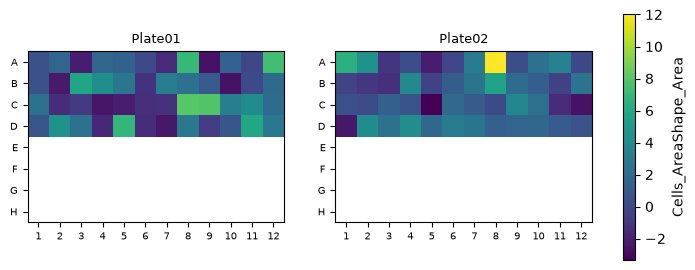

In [3]:
mt.pl.plate(cells, color=cells.var_names[0])

## What treating cells as replicates costs

`mt.metrics.diagnose_testing` relabels control cells as pseudo-treatments of whole control wells, where the
truth is known to be null, and reports each hit caller's false positive rate under two nulls side by side:

- the **cell-shuffle** null, which permutes single cells and so treats them as independent replicates, and
- the **well-block** null, which permutes whole wells, the unit the experiment actually randomized.

A calibrated test stays at or below the chance cutoff. Read the two rates against each other.

In [4]:
report = mt.metrics.diagnose_testing(cells, n_draws=8, n_permutations=50)
report

,check,value,expected,verdict,note
0,hit_calling well-block null rate,0 of 8,<= 2,pass,hit_calling called a control-only pseudo-treat...
1,hit_calling cell-shuffle null rate,8 of 8,<= 0 (well-block),FAIL,the same hit_calling null permuting single cel...
2,edistance well-block null rate,1 of 8,<= 2,pass,edistance called a control-only pseudo-treatme...
3,edistance cell-shuffle null rate,8 of 8,<= 1 (well-block),FAIL,the same edistance null permuting single cells...


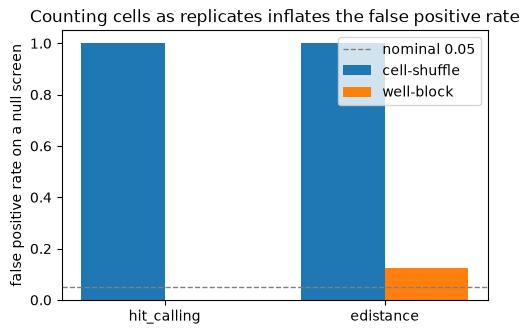

In [5]:
import matplotlib.pyplot as plt
import numpy as np

rates = report[report["check"].str.endswith("null rate")].copy()
rates["caller"] = rates["check"].str.split().str[0]
rates["kind"] = np.where(rates["check"].str.contains("cell-shuffle"), "cell-shuffle", "well-block")
rates["rate"] = rates["value"].apply(lambda v: int(v.split()[0]) / int(v.split()[-1]))

callers = ["hit_calling", "edistance"]
x = np.arange(len(callers))
width = 0.38
fig, ax = plt.subplots(figsize=(5.5, 3.5))
for offset, kind in ((-0.5, "cell-shuffle"), (0.5, "well-block")):
    heights = [rates[(rates["caller"] == c) & (rates["kind"] == kind)]["rate"].iloc[0] for c in callers]
    ax.bar(x + offset * width, heights, width, label=kind)
ax.axhline(0.05, linestyle="--", color="grey", linewidth=1, label="nominal 0.05")
ax.set_xticks(x)
ax.set_xticklabels(callers)
ax.set_ylabel("false positive rate on a null screen")
ax.set_title("Counting cells as replicates inflates the false positive rate")
ax.legend()
plt.show()

The tall cell-shuffle bars are the pitfall: counting cells as replicates makes pure noise look significant,
far above the nominal rate, and the verdict fails. The well-block bars, the rates to trust, sit near nominal.
The gap between the two is the pseudoreplication, measured on this screen rather than asserted. Each row of the
table names the block it draws whole and, for `hit_calling`, the method it measured, so the check describes the
test you mean to run.

## The default already draws whole wells

At cell resolution `tl.hit_calling` and `tl.distance` resample whole wells for their permutation null without
being asked, so the calibrated well-block rate above is what a plain call gives you. On this small screen the
caller goes further and warns that its null has few wells and is therefore only conservative, pointing to
`tl.aggregate` for an exact test: the tool says where it stands rather than returning a confident wrong
answer. On the null plate it calls nothing.

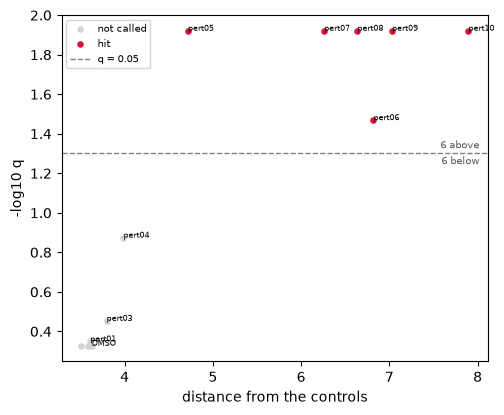

In [6]:
mt.tl.hit_calling(cells)
mt.pl.hits(cells)

## The other route: aggregate first

When the question is about the treatment rather than the cells, aggregate to the well with `tl.aggregate` and
test the wells with `tl.differential_features`, the pseudobulk approach single-cell settled on. The unit of
the test is then the unit that was randomized. That path is worked through in
[Which measurements moved](../phenotypes/which_features_moved.ipynb).

In [7]:
wells = mt.tl.aggregate(cells)
wells

AnnData object with n_obs × n_vars = 96 × 10
    obs: 'Metadata_Plate', 'Metadata_Well', 'Metadata_CellCount', 'Metadata_Row', 'Metadata_Col', 'Metadata_Perturbation', 'Metadata_Control', 'Metadata_Batch', 'Metadata_ImageNumber'
    var: 'object', 'feature_group', 'feature', 'channel', 'scale', 'angle', 'gray_levels', 'radial_bin', 'params', 'is_feature'
    uns: 'mantispy'
    layers: None (.X)

## Takeaway

- Cells within a well are not independent replicates; the well, or the plate, is the unit that was
  randomized.
- Testing at cell resolution is fine as long as the null resamples whole wells. `tl.hit_calling` and
  `tl.distance` do this by default.
- `mt.metrics.diagnose_testing` measures, on your own screen, whether the null is calibrated and what a
  cell-shuffle would cost, and names the exact method and block it checked.
- When the question is about the treatment, aggregate to wells with `tl.aggregate` and test with
  `tl.differential_features`, which refuses cell-level input for this reason.